### Block 1: Setup

#### Block 1.1: Import necessary libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit_aer import Aer
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import ClassicalRegister
import numpy as np

#### Block 1.2: Connect to Qiskit service

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, EstimatorV2

service = QiskitRuntimeService()
# Choose IBM Quantum backend
backend = service.backend('ibm_brisbane')

estimator = EstimatorV2(mode=backend)
sampler = SamplerV2(mode=backend)

### Block 2: Define the QET circuit & parameters

#### Block 2.1: Define QET circuit function

In [6]:
def qet_circuit(h, k, apply_h):
    """
    Constructs the quantum circuit for the QET experiment.

    Args:
      h: Parameter h for the Hamiltonian.
      k: Parameter k for the Hamiltonian.

    Returns:
      qc: The constructed QuantumCircuit object.
    """

    qc = QuantumCircuit(2, 2)

    # Prepare the ground state
    theta = -np.arccos(
        (1 / np.sqrt(2)) * np.sqrt(1 - h / np.sqrt(h**2 + k**2))
    )
    qc.ry(2 * theta, 0)
    qc.cx(0, 1)

    qc.h(0)
    
    # Alice's measurement
    qc.measure(0, 0)  # Measure qubit 0 into classical bit 0

    # Bob's conditional operation
    phi = np.arcsin(
        (h * k) / np.sqrt((h**2 + 2 * k**2)**2 + h**2 * k**2)
    ) / 2

    # Bob's conditional operation
    qc.ry(2 * phi, 1).c_if(0, 0)  # Apply U(+1) if classical bit 0 is 0
    qc.ry(-2 * phi, 1).c_if(0, 1)  # Apply U(-1) if classical bit 0 is 1

    if apply_h:
      qc.h(1)

    qc.measure(1, 1)  # Measure qubit 1 into classical bit 1

    return qc

#### Block 2.2: Define system parameters

In [7]:
h = 1.0
k = 1.0

total_shots = 2 ** 15

#### Block 2.3: Bob's `H1` circuit

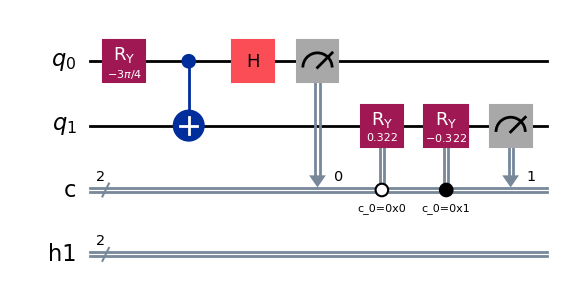

In [8]:
h1 = SparsePauliOp.from_list([("ZI", h), ("II", h**2 / np.sqrt(h**2 + k**2))])

qc_h1 = qet_circuit(h, k, False)
cr_h1 = ClassicalRegister(h1.num_qubits, 'h1')
qc_h1.add_register(cr_h1)

qc_h1_transpiled = transpile(qc_h1, backend)

circuit_drawer(qc_h1, output='mpl')

#### Block 2.4: Bob's `V` circuit

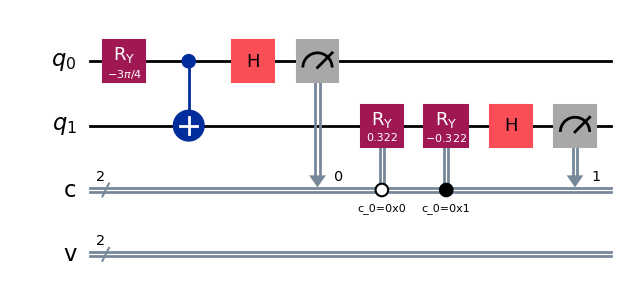

In [9]:
v = SparsePauliOp.from_list([("XX", 2 * k), ("II", 2 * k**2 / np.sqrt(h**2 + k**2))])

qc_v = qet_circuit(h, k, True)
cr_v = ClassicalRegister(v.num_qubits, 'v')
qc_v.add_register(cr_v)  # Add the ClassicalRegister

qc_v_transpiled = transpile(qc_v, backend)

circuit_drawer(qc_v, output='mpl')

### Block 3: Simulation

#### Block 3.1: Simulation run function

In [10]:
def run_sim(qc):
    # Use the Qiskit simulator
    simulator = Aer.get_backend('qasm_simulator')
    qc_compiled = transpile(qc, simulator)

    job_sim = simulator.run(qc_compiled, shots=total_shots)
    result_sim = job_sim.result()
    counts_sim = result_sim.get_counts(qc_compiled)

    return counts_sim

#### Block 3.2: Run simulation

In [11]:
h1_counts_sim = run_sim(qc_h1)
v_counts_sim = run_sim(qc_v)

h1_counts_sim = {k.removeprefix('00 '): v for k, v in h1_counts_sim.items()}
v_counts_sim = {k.removeprefix('00 '): v for k, v in v_counts_sim.items()}

#### Block 3.3: Plot simulation results

H1 Simulation results:
{'11': 11904, '00': 4483, '10': 11976, '01': 4405}


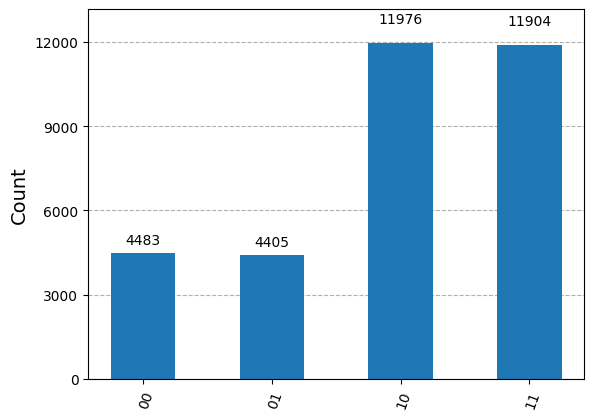

In [12]:
# Print and plot results
print("H1 Simulation results:")
print(h1_counts_sim)
plot_histogram(h1_counts_sim)

V Simulation results:
{'11': 861, '01': 15623, '00': 843, '10': 15441}


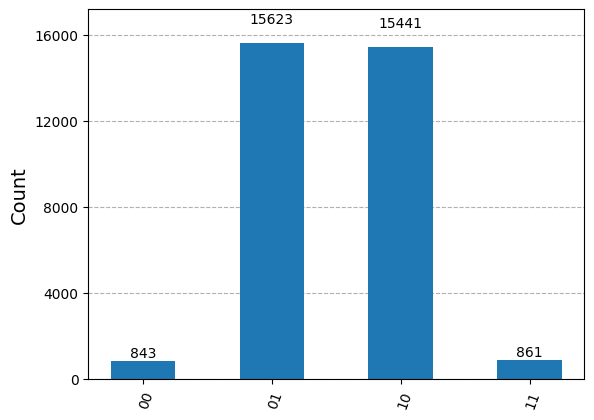

In [56]:
print("V Simulation results:")
print(v_counts_sim)
plot_histogram(v_counts_sim)

### Block 4: Raw Sampling on real quantum HW

#### Block 4.1: `H1` samplig

In [ ]:
h1_sam = h1.copy()
h1_sam.apply_layout(layout=qc_h1_transpiled.layout)

# Run the circuits and get quasi-probabilities
pub_h1 = (qc_h1_transpiled, [h1_sam], None)
raw_job_h1 = sampler.run([qc_h1_transpiled], shots=total_shots)
raw_result_h1 = raw_job_h1.result()

#### Block 4.2: `V` Samplig

In [ ]:
v_sam = v.copy()
v_sam.apply_layout(layout=qc_v_transpiled.layout)

# Run the circuits and get quasi-probabilities
pub_v = (qc_v_transpiled, [v_sam], None)
raw_job_v = sampler.run([qc_v_transpiled], shots=total_shots)
raw_result_v = raw_job_v.result()

#### Block 4.3: Plot raw sampling results

H1 Execution results:
{'01': 4759, '00': 4795, '11': 12532, '10': 10682}


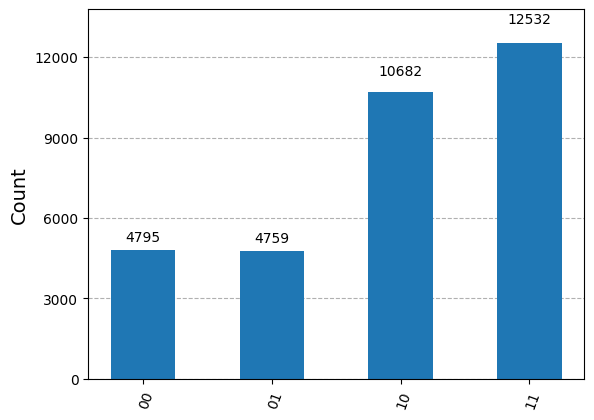

In [59]:
h1_counts_hw = raw_result_h1._pub_results[0].data.c.get_counts()

# Print and plot results
print("H1 Execution results:")
print(h1_counts_hw)
plot_histogram(h1_counts_hw)

V Execution results:
{'01': 11316, '10': 10427, '11': 5724, '00': 5301}


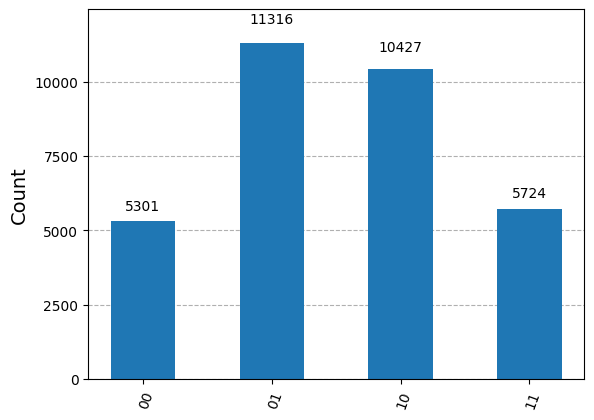

In [60]:
v_counts_hw = raw_result_v._pub_results[0].data.c.get_counts()

# Print and plot results
print("V Execution results:")
print(v_counts_hw)
plot_histogram(v_counts_hw)

### Block 5: Run Estimator on real quantum HW

#### Block 5.0: Prepare estimator configuration

TODO: Adjust parameters for error mitigation 

In [107]:
# estimator.options.default_shots = total_shots
# estimator.options.twirling.enable_gates = True
# estimator.options.twirling.num_randomizations = 64
# estimator.options.twirling.shots_per_randomization = 100

# estimator.options.dynamical_decoupling.enable = True
# estimator.options.dynamical_decoupling.sequence_type = "XpXm"

estimator.options.resilience.measure_mitigation = True
estimator.options.resilience.measure_noise_learning.num_randomizations = 64
estimator.options.resilience.measure_noise_learning.shots_per_randomization = 100

# estimator.options.resilience.zne_mitigation = True
# estimator.options.resilience.zne.noise_factors = (1, 3, 5)
# estimator.options.resilience.zne.extrapolator = "exponential"

estimator.options.resilience.zne_mitigation = True
estimator.options.resilience.zne.amplifier = "pea"

# estimator.options.resilience.pec_mitigation = True
# estimator.options.resilience.pec.max_overhead = 100

#### Block 5.1: Run `H1` Estimator

In [ ]:
# Execute the circuits and get expectation values
num_qubits_transpiled = qc_h1_transpiled.num_qubits
h1_expanded = SparsePauliOp.from_list([("Z" + "I" * (num_qubits_transpiled - 1), h),
                                     ("I" * num_qubits_transpiled, h**2 / np.sqrt(h**2 + k**2))])

pub_h1 = (qc_h1_transpiled, [h1_expanded], None)
job_h1 = estimator.run([pub_h1])
result_h1 = job_h1.result()

#### Block 5.2: Run `V` Estimator

In [ ]:
num_qubits_transpiled = qc_v_transpiled.num_qubits
v_expanded = SparsePauliOp.from_list([("XX" + "I" * (num_qubits_transpiled - 2), 2 * k),
                                     ("I" * num_qubits_transpiled, 2 * k**2 / np.sqrt(h**2 + k**2))])

pub_v = (qc_v_transpiled, [v_expanded], None)
job_v = estimator.run([pub_v])
result_v = job_v.result()

### Block 6: Analyze the results

#### Block 6.1: Calculate expectation values from classical bits results function

In [109]:
print(result_h1._pub_results[0].data['evs'])

1.6937391223160743


In [63]:
def calc_expectations(h1_counts, v_counts):
    z_expectation = 0
    xx_expectation = 0

    if h1_counts:
        for key, count in h1_counts.items():
            if key[1] == '0':  # Check the second bit for <H1>
                z_expectation += count
            else:
                z_expectation -= count

        z_expectation /= total_shots

    if v_counts:
        for key, count in v_counts.items():
            if key in ('11', '00'):
                xx_expectation += count
            else:
                xx_expectation -= count
        
        xx_expectation /= total_shots

    E1 = z_expectation + xx_expectation

    return (E1, z_expectation, xx_expectation)

#### Block 6.2: Simulation Expectation Values

In [64]:
E1, z_expectation, xx_expectation = calc_expectations(h1_counts_sim, v_counts_sim)
print(f'<H1> = {z_expectation}\t<V> = {xx_expectation}\t<E1> = {E1}')

<H1> = -0.00653076171875	<V> = -0.89599609375	<E1> = -0.90252685546875


#### Block 6.3: Raw Sampling Expectation Values

In [65]:
E1, z_expectation, xx_expectation = calc_expectations(h1_counts_hw, v_counts_hw)
print(f'<H1> = {z_expectation}\t<V> = {xx_expectation}\t<E1> = {E1}')

<H1> = -0.05535888671875	<V> = -0.32708740234375	<E1> = -0.3824462890625


#### Block 6.4: Raw Sampling & Simulation Plot

##### Block 6.4.1: `H1` histogram

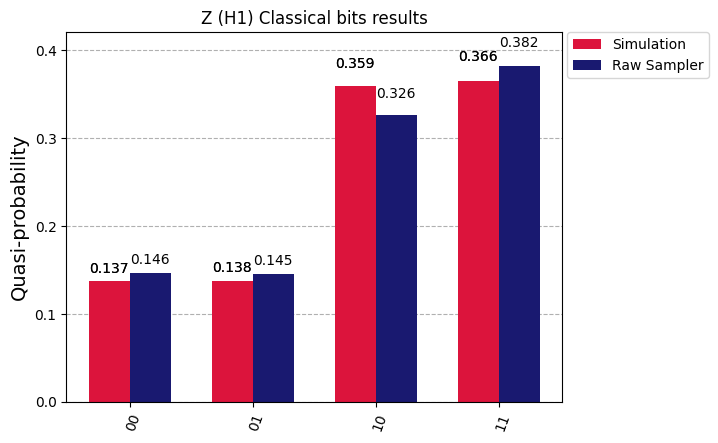

In [69]:
legend = ['Simulation', 'Raw Sampler']

h1_prob_sim = {k: v / total_shots for k, v in h1_counts_sim.items()}
h1_prob_hw = {k: v / total_shots for k, v in h1_counts_hw.items()}

plot_histogram([h1_prob_sim, h1_prob_hw], legend=legend, color=['crimson','midnightblue'],
                title="Z (H1) Classical bits results")

##### Block 6.4.1: `V` histogram

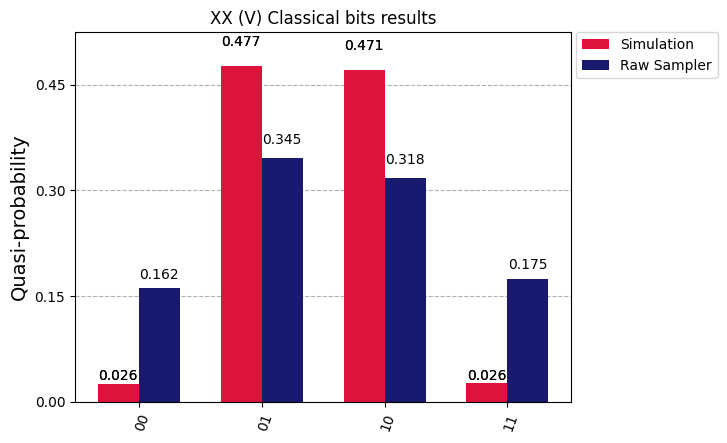

In [70]:
legend = ['Simulation', 'Raw Sampler']

v_prob_sim = {k: v / total_shots for k, v in v_counts_sim.items()}
v_prob_hw = {k: v / total_shots for k, v in v_counts_hw.items()}

plot_histogram([v_prob_sim, v_prob_hw], legend=legend, color=['crimson','midnightblue'],
                title="XX (V) Classical bits results")

#### Block 6.5: Estimator Expectation Values

In [68]:
print('H1 Results:')
print(f'<H1> = {result_h1._pub_results[0].data['evs']} +- {result_h1._pub_results[0].data['stds']}')

print()

print('V Results:')
print(f'<V> = {result_v._pub_results[0].data['evs']} +- {result_v._pub_results[0].data['stds']}')

H1 Results:
<H1> = 1.6724388124365475 +- 0.004078516188216757

V Results:
<V> = 1.424955749873095 +- 0.031249549236622882
